In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
#DEFINIMOS LA RUTA DE ENTRADA Y SALIDA 
ruta_processed = Path("data/processed")
# EL ARCHIVO QUE YA TENEMOS 
archivo_returns = ( ruta_processed / "SPY_2015_2025_returns.csv" )
#EL ARCHIVO QUE VAMOS A GENERAR
archivo_volatility = (ruta_processed / "SPY_2015_2025_volatility.csv")

In [4]:
#VERIFICAMOS QUE EL ARCHIVO EXISTA ANTES DE LEERLO
if not archivo_returns.exists():
   raise FileNotFoundError(f"No se encontro el archivo: {archivo_returns}")

In [5]:
#SE LEE Y NE INDEXA LA FECHA COMO INDICE, USANDO DATETIME PARA COMPARAR Y ORDENAR TEMPORALMENTE
datos_returns = pd.read_csv(archivo_returns,index_col=0, parse_dates=True)
#CREAMOS UNA COPIA INDEPENDIENTE EN LA MEMORIA
datos = datos_returns.copy(deep=True)

In [6]:
#REVISAMOS LA FORMA, RANGO DE FECHAS Y COLUMNAS
print(datos.shape)
print(datos.index.min())
print(datos.index.max())
print(datos.columns.tolist()) #LISTA DE NOMBRES DE COLUMNAS A VERIFICAR
datos.head()

(2765, 9)
2015-01-05 00:00:00
2025-12-31 00:00:00
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return', 'Abs_Return', 'Sq_Return']


,Open,High,Low,Close,Adj Close,Volume,Return,Abs_Return,Sq_Return
Date,,,,,,,,,
2015-01-05,204.169998,204.369995,201.350006,201.720001,166.623337,169632600,-0.018225,0.018225,0.000332
2015-01-06,202.089996,202.720001,198.860001,199.820007,165.053909,209151400,-0.009464,0.009464,0.000090
2015-01-07,201.419998,202.720001,200.880005,202.309998,167.110703,125346700,0.012384,0.012384,0.000153
2015-01-08,204.009995,206.160004,203.990005,205.899994,170.076080,147217800,0.017589,0.017589,0.000309
2015-01-09,206.399994,206.419998,203.509995,204.250000,168.713120,158567300,-0.008046,0.008046,0.000065


In [7]:
#DEFINIMOS LAS COLUMNAS QUE NECESITAMOS
columnas_necesarias = ["Adj Close","Return","Abs_Return","Sq_Return"]
# DETECTAMOS SI HAY COLUMNAS FALTANTES
faltantes = [col for col in columnas_necesarias if col not in datos.columns]
#CONDICIONAMOS Y DETIENE EL PROGRAMA
assert len(faltantes) == 0, ( f"Faltan columnas: {faltantes}")

In [8]:
#VERIFICA QUE LA FECHA ESTE EN ORDEN ASCENDENTE
assert datos.index.is_monotonic_increasing
# VERIFICA QUE NO HAYA FECHAS REPETIDAS
assert datos.index.is_unique

In [9]:
#NOS DA LOS VALORES FALTANTES EN LA COLUMNAS
assert not datos["Return"].isna().any()
assert not datos["Abs_Return"].isna().any()
assert not datos["Sq_Return"].isna().any()

In [10]:
# NOS DA LOS VALORES FINITOS 
assert np.isfinite(datos["Return"]).all()


ESTO NOS AYUDA A REVISAR QUE EL ARCHIVO DE ENTRADA ESTE BIEN ORDENADO Y LIMPIO ANTES DE USARLO

In [11]:
#DEFINIMOS LA VENTANAS QUE USAREMOS, ES DECIR BUSCA CUBRIR UN RANGO DE ESCALAS TEMPORALES
ventanas = [5, 10, 20, 30]

In [12]:
#RECORRE CADA VENTANA Y LO GUARDA DENTRO DE UN DATAFRAME  
for w in ventanas: datos[f"Vol_{w}"] = (datos["Return"].rolling(window=w)
 .std(ddof=1))

In [13]:
#CALCULAMOS LA DESVIACION ESTANDAR DE LAS 4 VENTANAS USANDO LOSN RENDIMIENTOS 
columnas_vol = ["Return","Vol_5","Vol_10","Vol_20","Vol_30"]
datos[columnas_vol].head(35)

,Return,Vol_5,Vol_10,Vol_20,Vol_30
Date,,,,,
2015-01-05,-0.018225,NaN,NaN,NaN,NaN
2015-01-06,-0.009464,NaN,NaN,NaN,NaN
2015-01-07,0.012384,NaN,NaN,NaN,NaN
2015-01-08,0.017589,NaN,NaN,NaN,NaN
2015-01-09,-0.008046,0.015351,NaN,NaN,NaN
2015-01-12,-0.007864,0.012987,NaN,NaN,NaN
2015-01-13,-0.002817,0.011958,NaN,NaN,NaN
2015-01-14,-0.006055,0.010842,NaN,NaN,NaN
2015-01-15,-0.009203,0.002494,NaN,NaN,NaN


In [14]:
# ENCONTRAMOS LOA VALORES NULOS REALES QUE SE PRODUJO
print(datos[["Vol_5", "Vol_10", "Vol_20", "Vol_30"]].isna().sum())

Vol_5      4
Vol_10     9
Vol_20    19
Vol_30    29
dtype: int64


In [15]:
#CREA UN DICIONARIO Y AUTOVERIFICA EL CODIGO EN CASO DE QUE HAYA ALGUN FALTANTE MAYOR AL DE LA TEORIA
esperados = {"Vol_5": 4,"Vol_10": 9,"Vol_20": 19,"Vol_30": 29}
for variable, n_nan in esperados.items():
    assert datos[variable].isna().sum() == n_nan

In [16]:
#SELECCIONA LAS PRIMERAS 5 FILAS DE LA COLUMNA RETURN SIN IMPORTAR LA FECHA
primeros_cinco = datos["Return"].iloc[:5]
print(primeros_cinco)

Date
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
2015-01-09   -0.008046
Name: Return, dtype: float64


VERIFICAMOS LA VOLATILIDAD DEL VOL_5

In [17]:
# SE CALCULA LA DESVIACION ESTANDAR SOBRE ESOS 5 VALORES DE FORMA MANUAL
vol_manual = primeros_cinco.std(ddof=1)

In [18]:
#TRAE EL VALOR QUE CALCULO ROLLING 
vol_rolling = datos["Vol_5"].iloc[4]
print("Calculo manual:", vol_manual)
print("Rolling:", vol_rolling)

Calculo manual: 0.015350579757951816
Rolling: 0.015350579757951816


In [19]:
# SI ASSERT PASA, CONFIRMA ROLLING, ES DECIR ES LA FORMULA TEORICA
assert np.isclose(vol_manual, vol_rolling)

VALIDAMOS VALORES DE 100  EN UNA VENTANA DE 20 DIAS 

In [20]:
w = 20
i = 100
ventana_manual = (datos["Return"].iloc[i-w+1:i+1])
vol_manual = ventana_manual.std(ddof=1)
vol_python = datos["Vol_20"].iloc[i]

print("Inicio:", ventana_manual.index[0])
print("Fin:", ventana_manual.index[-1])
print("Observaciones:", len(ventana_manual))
print("Manual:", vol_manual)
print("Python:", vol_python)

assert len(ventana_manual) == w
assert np.isclose(vol_manual, vol_python)

Inicio: 2015-05-01 00:00:00
Fin: 2015-05-29 00:00:00
Observaciones: 20
Manual: 0.006743880382935541
Python: 0.006743880382935538


SE REPITE LA MISMA LOGICA DE LA SECCION 14, USANDO UN PUNTO A LA MITAD DE LA SERIE PARA ASEGURAR QUE NO FUE SUERTE

In [22]:
#OBTENEMOS LA VOLATILIDAD ANUALIZADA Y DIARIA
for w in ventanas:
    datos[f"Vol_{w}_Annual"] = (datos[f"Vol_{w}"] * np.sqrt(252))

1. Obtenga estadísticas descriptivas de las cuatro medidas de volatilidad Vol_5, Vol_10, Vol_20
y Vol_30 y compare sus medias, desviaciones estándar y valores máximos.

In [23]:
#HACEMOS UN RESUMEN ESTADISTICO
variables_vol = ["Vol_5","Vol_10","Vol_20","Vol_30"]
resumen_vol = (datos[variables_vol].describe().T)
resumen_vol

,count,mean,std,min,25%,50%,75%,max
Vol_5,2761.0,0.008791,0.007325,0.000426,0.004479,0.007091,0.010876,0.089662
Vol_10,2756.0,0.009133,0.006746,0.001264,0.005180,0.007526,0.011217,0.071223
Vol_20,2746.0,0.009390,0.006300,0.002007,0.005705,0.007699,0.011503,0.059167
Vol_30,2736.0,0.009541,0.006062,0.002212,0.006097,0.007854,0.011540,0.052091


Las medias sube ligeramente conforme crece la ventana, entre periodos mas largos la volatilidad se estabiliza.   
la desviacion va bajando conforme crece la ventana, es decir que vol_5 es la mas inestable  de las 4 porque varia de una dia para otro y sube y baja con fuerza.   
en los maximos se duplica entre vol_30 y vol_5 

4. Calcule la matriz de correlación entre las cuatro volatilidades. Explique por qué pueden
estar altamente correlacionadas sin ser idénticas.

In [24]:
#OBTENEMOS LA MATRIZ DE CORRELACION DE PEARSON, MUESTRA QUE TAN RELACIONADOS
# ESTAN LOS DATOS 
correlaciones = datos[variables_vol].corr()
correlaciones

,Vol_5,Vol_10,Vol_20,Vol_30
Vol_5,1.000000,0.900827,0.785143,0.706099
Vol_10,0.900827,1.000000,0.904343,0.818438
Vol_20,0.785143,0.904343,1.000000,0.943681
Vol_30,0.706099,0.818438,0.943681,1.000000


ENTRE MAS PARECIDOS ES EL TAMANO DE LAS VENTANAS MAS CORRELACIONADAS ESTAN, LA PAREJA MAS CORRELACIONADA ES VOL_30 Y VOL_20 PORQUE TIENE CASI EL TAMANO DE DIAS. LA MENOS CORRELACIONADA ES LA VOL_5 Y VOL_30 PORQUE LA DIFERENCIA DE DIAS ES MAYOR.   
NOTAMOS QUE NINGUNA DE LAS COMBINACIONES BAJA DE 0.70 , INDICA UNA CORRELACION FUERTE, DEBIDO A QUE SE CALCULAN SOBRE LA MISMA SERIE DE RENDIMIENTOS Y RESPONDEN A LOS MISMO EVENTOS DEL MERCADO. 

2. Grafique conjuntamente Vol_5, Vol_10, Vol_20 y Vol_30. Describa el efecto del tamaño de
la ventana.

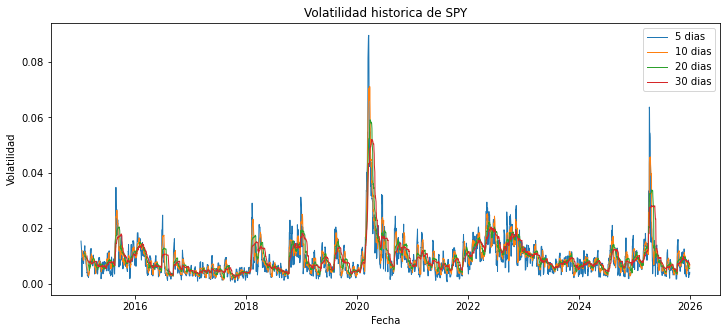

In [26]:
#VISUALIZAMOS LA VENTANAS  POR MEDIO DE MAPAS DE CALOR 
fig, ax = plt.subplots(figsize=(12, 5))
for w in ventanas: #POR CADA VENTANA HAZ UNA LIENA DISTINTA
    ax.plot(datos.index,datos[f"Vol_{w}"],label=f"{w} dias",linewidth=1)
ax.set_title("Volatilidad historica de SPY")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volatilidad")
ax.legend()
plt.show()

Los picos mas altos es de la ventana 5, la mas plana es la de ventana 30. Aunque tienen distinta suavidad generalmente suben y bajan en los mismos periodos

NOTAMOS QUE LA CURVA MAS NERVIOSA ES LA DE VOL_5, LA MAS SUAVE ES VOL_30 Y LOS PICOS DE ALTA VOLATILIDAD OCURREN EN LAS MISMAS FECHAS PARA TODAS.

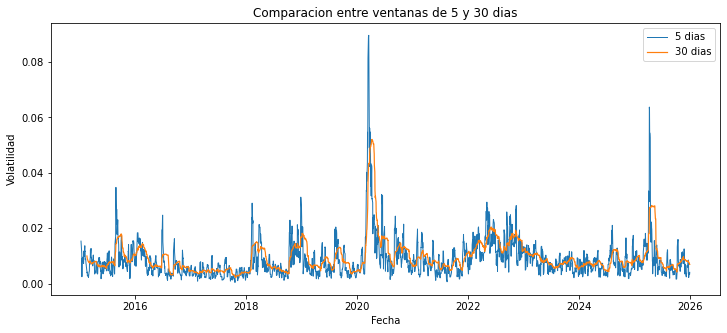

In [27]:
#HACEMOS LA COMPARACION DE VOL_5 Y VOL_30, ES DECIR LA RELACION ENTRE RAPIDEZ DE REACCION Y DE SUAVIZAMIENTO
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(datos.index,datos["Vol_5"],label="5 dias",linewidth=1)
ax.plot(datos.index,datos["Vol_30"],label="30 dias",linewidth=1.2)
ax.set_title("Comparacion entre ventanas de 5 y 30 dias")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volatilidad")
ax.legend()
plt.show()

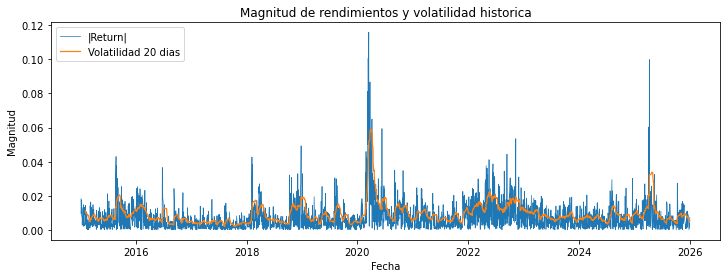

In [28]:
#GRAFICAMOS RENDIMIENTOS ABSOLUTOS Y VOLATILIDAS HISTORICA
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(datos.index, datos["Abs_Return"],linewidth=0.7,label="|Return|")
ax.plot(datos.index, datos["Vol_20"], linewidth=1.2, label="Volatilidad 20 dias" )
ax.set_title("Magnitud de rendimientos y volatilidad historica" )
ax.set_xlabel("Fecha")
ax.set_ylabel("Magnitud")
ax.legend()
plt.show()

ABS_RETURNS SE VE COMO PICOS AISLADOS Y PUNTIAGUDOS Y EL VOL_20 SE VE COMO UNA CURVA MAS SUAVE QUE SUBE DESPUES DE UN PICO GRANDE Y TARDA EN VOLVER A BAJAR VARIOS DIAS.

In [29]:
mayor_volatilidad = (datos[[ "Adj Close", "Return", "Vol_5", "Vol_10", "Vol_20", "Vol_30"]]
.dropna().nlargest(10, "Vol_20")) #ELIMINA LOS NANS DE LAS COLUMNAS Y TOMA 1O FILAS CON EL VALOR MAS ALTO
mayor_volatilidad # DA LOS 10 PERIODOS MAS TURBULENTOS 

,Adj Close,Return,Vol_5,Vol_10,Vol_20,Vol_30
Date,,,,,,
2020-03-27,232.355545,-0.030238,0.051136,0.060632,0.059167,0.048928
2020-03-26,239.488861,0.056749,0.054800,0.065722,0.058926,0.048788
2020-03-30,239.901505,0.031960,0.044089,0.047279,0.058748,0.049473
2020-03-31,236.325638,-0.015018,0.035080,0.045187,0.058567,0.049475
2020-04-02,230.897690,0.022813,0.033672,0.044855,0.058255,0.050224
2020-04-03,227.560303,-0.014559,0.031674,0.042146,0.058242,0.050233
2020-04-01,225.689850,-0.046049,0.043304,0.044427,0.058010,0.049866
2020-04-06,242.844666,0.065007,0.042646,0.043762,0.057837,0.051810
2020-03-25,226.276657,0.014859,0.050326,0.070786,0.057611,0.047315


In [47]:
mayor_volatilidad_20 = (datos[[ "Adj Close", "Return",'Abs_Return', "Vol_20"]]
.dropna().nlargest(10, "Vol_20"))
mayor_volatilidad_abs = (datos[[ "Adj Close", "Return",'Abs_Return', "Vol_20"]]
.dropna().nlargest(10, "Abs_Return"))
print(mayor_volatilidad_20.index)
print(mayor_volatilidad_abs.index)

DatetimeIndex(['2020-03-27', '2020-03-26', '2020-03-30', '2020-03-31',
               '2020-04-02', '2020-04-03', '2020-04-01', '2020-04-06',
               '2020-03-25', '2020-03-24'],
              dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2020-03-16', '2020-03-12', '2025-04-09', '2020-03-24',
               '2020-03-13', '2020-03-09', '2020-04-06', '2025-04-04',
               '2020-06-11', '2020-03-26'],
              dtype='datetime64[ns]', name='Date', freq=None)


NOTAMOS QUE NO SON LAS MISMAS FECHAS, SOLO SE REPITEN 3 ENTRE AMBAS LISTAS Y OCURRE PORQUE VOL_20 MIDE UN PERIODO, MIENTRAS QUE ABS_RETURN MIDE EVENTOS DE UN SOLO DIA QUE PUEDE OCURRIR DE FORMA AISLADA EN CUALQUIER MOMENTO SIN QUE ESE MOMENTO PERNEZCA A UN PERIODO PROLONGADO

In [31]:
#SI MENOR A 1 EL MERCADO ES MAS TRANQUILO EN EL CORTO PLAZO 
datos["Ratio_Vol_5_30"] = (datos["Vol_5"] /datos["Vol_30"])
datos["Ratio_Vol_5_30"]

Date
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
2015-01-09         NaN
                ...   
2025-12-24    0.287808
2025-12-26    0.437836
2025-12-29    0.559601
2025-12-30    0.478327
2025-12-31    0.585764
Name: Ratio_Vol_5_30, Length: 2765, dtype: float64

In [32]:
for w in ventanas:valores = datos[f"Vol_{w}"].dropna()
assert (valores >= 0).all()
#POR  CADA VENTANA QUITA LOS NAN Y VERIFICA QUE TODOS LOS DATOS SEAN >=0

In [33]:
for w in ventanas:valores = datos[f"Vol_{w}"].dropna()
assert np.isfinite(valores).all()
# NO DEBE HABER NINGUN INF O -INF

In [35]:
for w in ventanas:
    assert ( datos[f"Vol_{w}"].isna().sum()== w - 1)
#COMPROBAMOS EL NUMERO CORRECTO DE NAN

In [45]:
# SE CREA LA LISTA FINAL DE COLUMNAS QUE QUEREMOS CONSERVAR DE FROMA INDEPENDIENTE
columnas_finales = [
"Open","High","Low","Close","Adj Close","Volume","Return","Abs_Return", "Sq_Return",
"Vol_5","Vol_10","Vol_20","Vol_30"]
datos_vol = datos[columnas_finales].copy()

In [39]:
# EXPORTAMOS 
datos_vol.to_csv(archivo_volatility,index=True)

In [40]:
verificacion = pd.read_csv(archivo_volatility,index_col=0, parse_dates=True )
assert verificacion.shape == datos_vol.shape
assert verificacion.index.is_monotonic_increasing
assert verificacion.index.is_unique
#LEEMOS EL ARCHIVO QUE GURDAMOS PARA CONFIRMAR LA EXPORTACION Y COMPARA LA FORMA
# DEL ARCHIVO LEIDO PARA QUE COINCIDAN, ASI MISMO EL ORDEN TEMPORAL

In [42]:
for w in ventanas:
    columna = f"Vol_{w}"
assert columna in verificacion.columns
assert verificacion[columna].isna().sum() == w - 1
#CONFIRMAMOS QUE LA COLUMNA EXISTE EN EL ARCHIVO EXPORTADO Y SE CONSERVA EXACTAMENTE
